In [2]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.8 MB 15.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.8 MB 14.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.8 MB 13.0 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 12.2 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -----

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [7]:
df=pd.read_csv('stock_data.csv',parse_dates=True,index_col='Date')

In [8]:
df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,Name
Date,,,,,,,
2006-01-03,NaN,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,NaN,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,NaN,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,NaN,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,NaN,43.10,43.66,42.82,43.42,16268338,AABA


In [12]:
df1=df.drop(columns='Unnamed: 0')

In [13]:
df1.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [15]:

print(df1.dtypes)


Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
Name       object
dtype: object


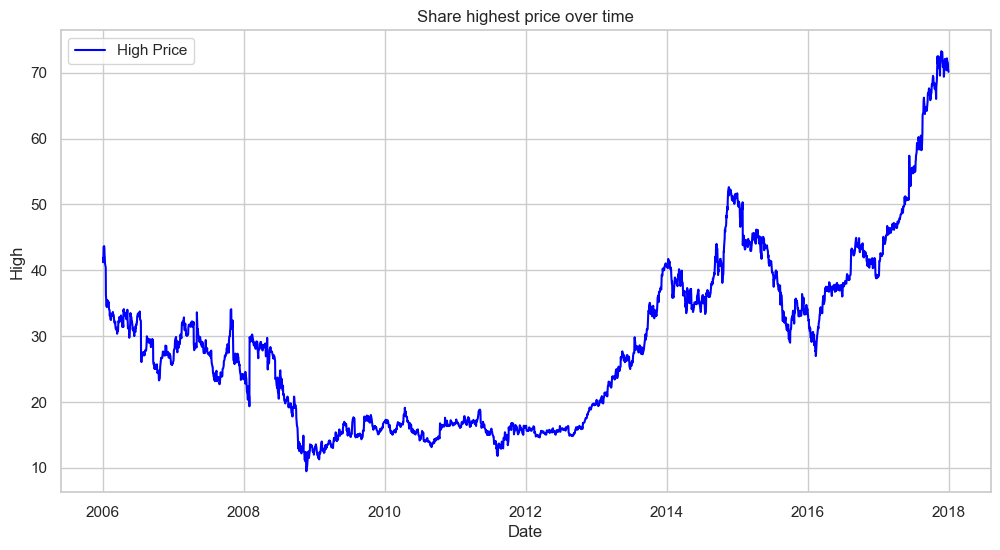

In [17]:
sns.set(style='whitegrid')

plt.figure(figsize=(12,6))  # set dim of figure of chart (width,height) in inches
sns.lineplot(data=df1,x='Date',y='High',label='High Price',color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share highest price over time')

plt.show()

In [18]:
## To better understand the trend of the data we will use the resampling method 
## which provide a clearer view of trends and patterns when we are dealing with daily data.

In [19]:
df2=df1.resample('M').mean(numeric_only=True)
df2.head()

C:\Users\91637\AppData\Local\Temp\ipykernel_20900\3391624478.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df2=df1.resample('M').mean(numeric_only=True)


,Open,High,Low,Close,Volume
Date,,,,,
2006-01-31,38.245500,38.694000,37.641500,38.113000,3.400594e+07
2006-02-28,33.141579,33.436842,32.627368,32.975789,2.329848e+07
2006-03-31,31.333478,31.696957,30.929130,31.218696,2.095522e+07
2006-04-30,32.383684,32.790000,31.914737,32.283158,2.200768e+07
2006-05-31,31.744545,32.175455,31.171364,31.517273,2.218047e+07


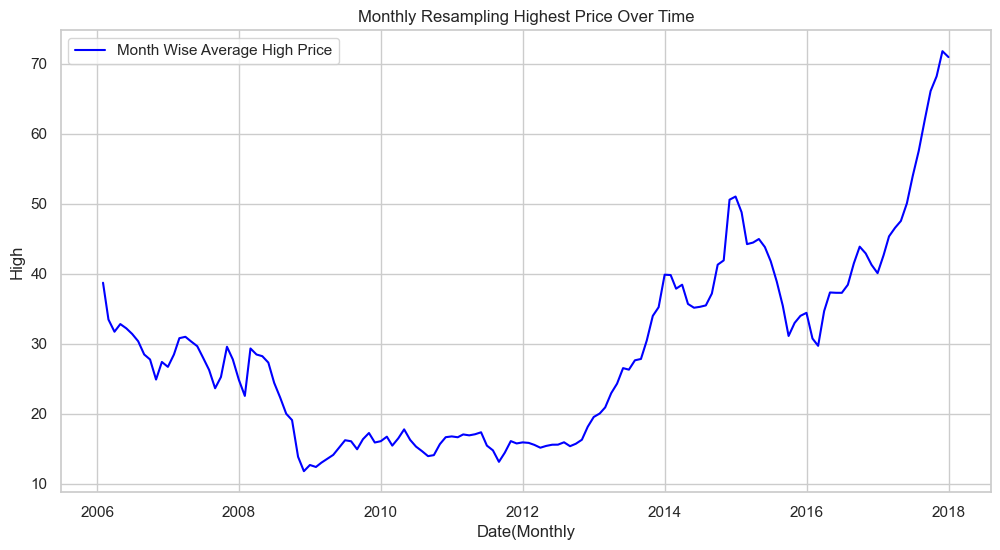

In [21]:


sns.set(style='whitegrid')

plt.figure(figsize=(12,6))  # set dim of figure of chart (width,height) in inches
sns.lineplot(data=df2,x='Date',y='High',label='Month Wise Average High Price',color='blue')

plt.xlabel('Date(Monthly')
plt.ylabel('High')
plt.title('Monthly Resampling Highest Price Over Time')

plt.show()

In [22]:
## Noise is removed by Resampling as now data is being seen in monthly fluctuations instead of daily

In [23]:
## We will detect Seasonality using the autocorrelation function (ACF) plot. 
## Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

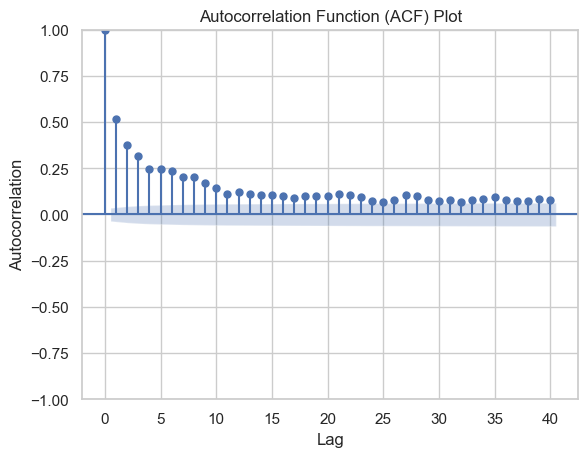

In [24]:
if 'Date' not in df.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
    df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plot_acf(df['Volume'], lags=40) 
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()

In [25]:
# No seasonality

In [26]:
## Testing Stationarity with ADF test

In [28]:
result= adfuller(df1['High'])
print('ADF Statistics:', result[0])
print('p-value:',result[1])
print('Critical Value:',result[4])

ADF Statistics: 0.7671404880535945
p-value: 0.9910868050318213
Critical Value: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


In [29]:
## Differencing to Achieve Stationarity

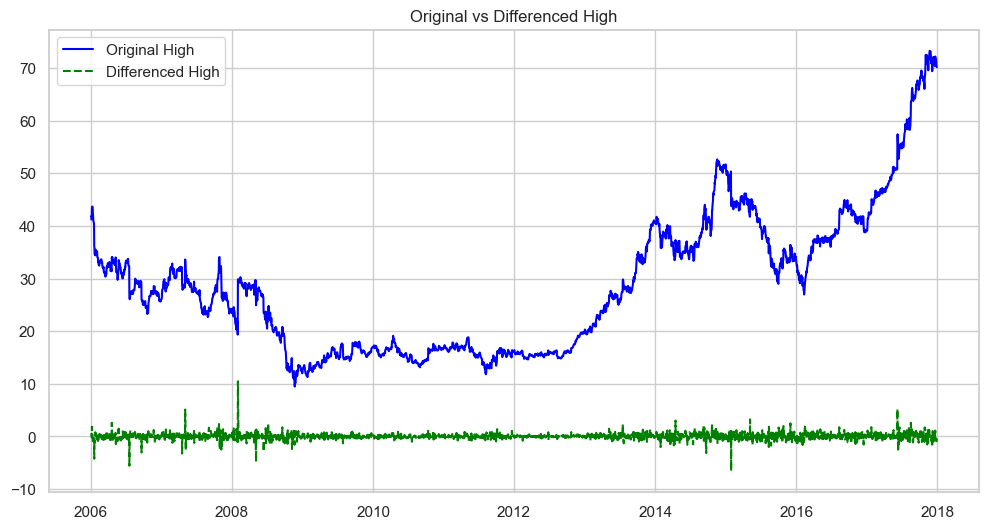

In [30]:
df1['high_diff'] = df1['High'].diff()

plt.figure(figsize=(12, 6))
plt.plot(df1['High'], label='Original High', color='blue')
plt.plot(df1['high_diff'], label='Differenced High', linestyle='--', color='green')
plt.legend()
plt.title('Original vs Differenced High')
plt.show()

In [31]:
## Smoothing Data with Moving Average

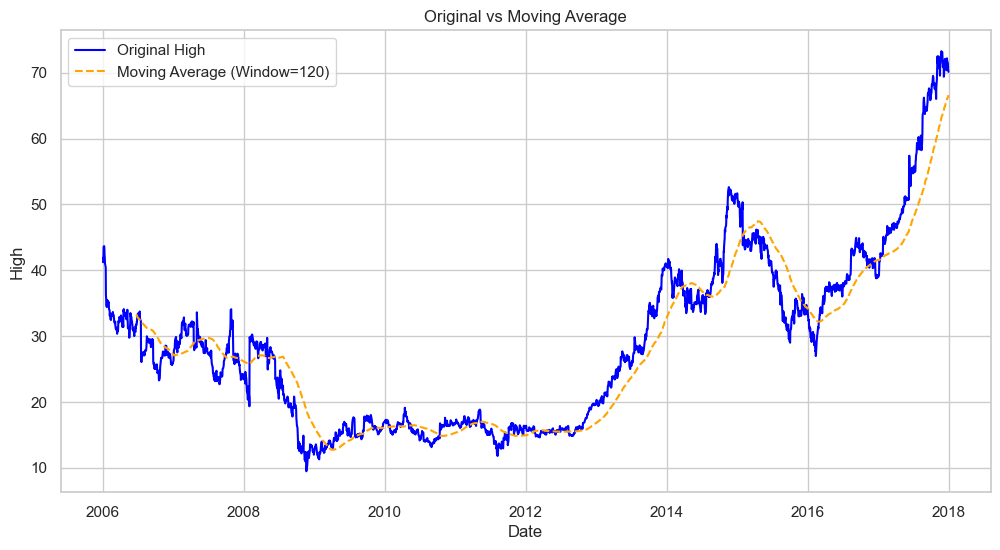

In [34]:
window_size = 120   ## window size means the the no. of time steps over which moving avg is calculated
df1['high_smoothed'] = df1['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df1['High'], label='Original High', color='blue')
plt.plot(df1['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

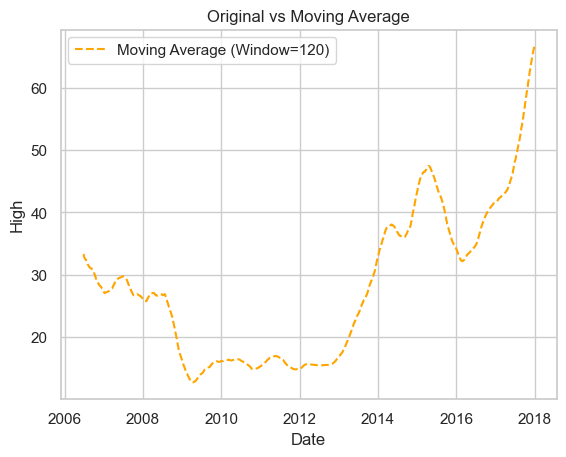

In [35]:
plt.plot(df1['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

In [36]:
## Original Data Vs Differenced Data

In [38]:
df3 = pd.concat([df1['High'], df1['high_diff']], axis=1)

print(df3.head())

             High  high_diff
Date                        
2006-01-03  41.22        NaN
2006-01-04  41.90       0.68
2006-01-05  41.73      -0.17
2006-01-06  43.57       1.84
2006-01-09  43.66       0.09


In [39]:
df3.dropna(subset=['high_diff'], inplace=True)  # drop NA value
df3['high_diff'].head()

Date
2006-01-04    0.68
2006-01-05   -0.17
2006-01-06    1.84
2006-01-09    0.09
2006-01-10   -0.32
Name: high_diff, dtype: float64

In [40]:
# After that if we conduct the ADF test:

In [41]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df3['high_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -12.14836747834325
p-value: 1.5912766134148354e-22
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


In [ ]:
# Null hypothesis: The null hypothesis assumes that there is no effect, no relationship, or no difference between variables or groups.